# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head

<bound method NDFrame.head of       user_id first_name last_name  age      city  \
0       10000     Carlos    Garcia   38  Medellín   
1       10001      Mateo    Torres   53         ?   
2       10002      Sofia   Ramirez   57      CDMX   
3       10003      Mateo   Ramirez   69    Bogotá   
4       10004      Mateo    Torres   63       GDL   
...       ...        ...       ...  ...       ...   
3995    13995        Ana     Lopez   60  Medellín   
3996    13996     Carlos   Ramirez   24  Medellín   
3997    13997        Ana     Lopez   58    Bogotá   
3998    13998    Mariana     Lopez   57    Bogotá   
3999    13999        Ana     Lopez   20    Bogotá   

                           reg_date     plan churn_date  
0     2022-01-01 00:00:00.000000000   Basico        NaN  
1     2022-01-01 06:34:17.914478619   Basico        NaN  
2     2022-01-01 13:08:35.828957239   Basico        NaN  
3     2022-01-01 19:42:53.743435858  Premium        NaN  
4     2022-01-02 02:17:11.657914478   Basic

In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isnull().sum().sum())
print(users.isna().mean())

4003
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isnull().sum().sum())
print(usage.isna().mean())

40022
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  En user, solo hay una columna que tiene el 10% de nulls, en usage, encontramos que se tiene el 55% de nulos en la columna de duration, el 45% en la columna de lenght y el 0.1% en la columna de date.
- Indica qué harías: ¿imputar, eliminar, ignorar?
  En la columna de city, sería investigar los datos, en la de churn_date validaríamos la columna para confirmar su uso, si no, eliminarla por completo. En la columna de duration y lenght, imputaría, ya que estamos hablando del 50% de la información. Y en la columna de date, ignoraría por completo los nulls ya que no me afecta esa cantidad de faltantes.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` cuenta con unos datos bastante estables, no parece haber ningún valor fuera de rango ya que su disperción es bastante estandar.
- La columna `age` tiene el valor mínimo imposible que nos llegará a afectar en el promedio

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` tienen la misma cuenta, lo que difiere de la columna duration y length.
- Las columnas duration y lenght tienen valores muy altos que afectan en la media y el promedio.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users['city'].describe())
print()
print(users['plan'].describe())

count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object


- La columna `city` cuenta con 7 valores únicos, sin embargo el más repetido es una cuarta parte del conteo total y hacen falta 500 datos según el conteo de la columna plan
- La columna `plan` solo tiene 2 opciones de plan y el Basico se repite poco más del 50% por lo que parece normal.

In [15]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` solo cuenta con 2 tipos de respuesta. Y el top tiene una frecuencia poco mayor al 50%, seguimos con el mismo conteo así que parece normal


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  En la columna city hacen falta valores por lo que podemos decir que hay valores inválidos
- ¿Qué acción tomarías?
  Se tendría que investigar la columna para determinar si se necesita imputar.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [18]:
# Revisar los años presentes en `reg_date` de users
years_in_reg_date = users['reg_date'].dt.year.unique()
print("Años presentes en reg_date:", sorted(years_in_reg_date))

Años presentes en reg_date: [2022, 2023, 2024, 2026]


En `reg_date`, contamos con 4 años totales. Y podemos considerar el 2026 como año futuro.

In [19]:
# Revisar los años presentes en `date` de usage
years_in_reg_date = usage['date'].dt.year.unique()
print("Años presentes en date:", sorted(years_in_reg_date))

Años presentes en date: [2024.0, nan]


En `date`, tenemos 1 datos inválido. 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  No, sólo aparece un na.
- ¿Qué harías con ellas?
  Confirmar la cantidad de na que tenemos y validar si son imputables o eliminables.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?','NA')

# Verificar cambios
users['city'].describe()

count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
from datetime import datetime
fecha_actual = datetime.now()

fechas_futuras = users['reg_date'] > fecha_actual
print(f"Fechas futuras encontradas: {fechas_futuras.sum()}")

users.loc[users['reg_date'] > fecha_actual, 'reg_date'] = pd.NaT
# Verificar cambios
print("Verificación después del reemplazo:")
print(f"Valores nulos en reg_date: {users['reg_date'].isnull().sum()}")
print(f"Fecha más reciente: {users['reg_date'].max()}")

Fechas futuras encontradas: 40
Verificación después del reemplazo:
Valores nulos en reg_date: 40
Fecha más reciente: 2024-12-31 00:00:00


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
nulos_por_tipo = usage.groupby('type').agg({
    'duration': lambda x: x.isnull().sum()
}).reset_index()

print(nulos_por_tipo)

print("Verificación MAR:")
print("¿Todos los 'text' tienen duration nula?", 
      usage[usage['type'] == 'text']['duration'].isnull().all())

   type  duration
0  call       0.0
1  text   22076.0
Verificación MAR:
¿Todos los 'text' tienen duration nula? False


In [24]:
# Verificación MAR en usage (Missing At Random) para length
nulos_por_tipo = usage.groupby('type').agg({
    'length': lambda x: x.isnull().sum()
}).reset_index()

print(nulos_por_tipo)

print("Verificación MAR:")
print("¿Todas las 'call' tienen duration válida?", 
      usage[usage['type'] == 'call']['duration'].notnull().all())

   type   length
0  call  17896.0
1  text      0.0
Verificación MAR:
¿Todas las 'call' tienen duration válida? True


Al parecer nuestros datos de duration y length ya no cuentan con nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    # Contar mensajes (type == 'text')
    'type': [
        lambda x: (x == 'text').sum(),  # cantidad de mensajes
        lambda x: (x == 'call').sum()   # cantidad de llamadas
    ],
    # Sumar minutos de llamadas (solo donde duration no es nulo)
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

user_id       type            duration
          <lambda_0> <lambda_1>      sum
0   10000          7          3    23.70
1   10001          5         10    33.18
2   10002          5          2    10.74

In [26]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Verificar resultado
print("Primeras filas de la tabla agregada:")
# observar resultado
print(usage_agg.head(3))

Primeras filas de la tabla agregada:
   user_id  cant_mensajes  cant_llamadas  cant_minutos_llamada
0    10000              7              3                 23.70
1    10001              5             10                 33.18
2    10002              5              2                 10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

print(f"Filas en users: {len(users)}")
print(f"Filas en users_completo: {len(user_profile)}")
print(f"Nuevas columnas: {list(user_profile.columns[-3:])}")
user_profile.head(5)

Filas en users: 4000
Filas en users_completo: 4000
Nuevas columnas: ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Resumen estadístico completo
print("=== RESUMEN ESTADÍSTICO - VARIABLES NUMÉRICAS ===")
resumen_numerico = user_profile[columnas_numericas].describe()
print(resumen_numerico)

# Información adicional útil
print("\n=== INFORMACIÓN ADICIONAL ===")
for col in columnas_numericas:
    print(f"\n{col.upper()}:")
    print(f"  • Valores nulos: {user_profile[col].isnull().sum()}")
    print(f"  • Media vs Mediana: {user_profile[col].mean():.2f} vs {user_profile[col].median():.2f}")
    if user_profile[col].mean() > user_profile[col].median():
        print(f"    → Distribución sesgada hacia la derecha (outliers altos)")
    else:
        print(f"    → Distribución relativamente simétrica")

=== RESUMEN ESTADÍSTICO - VARIABLES NUMÉRICAS ===
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000

=== INFORMACIÓN ADICIONAL ===

AGE:
  • Valores nulos: 0
  • Media vs Mediana: 48.14 vs 48.00
    → Distribución sesgada hacia la derecha (outliers altos)

CANT_MENSAJES:
  • Valores nulos: 1
  • Media vs Mediana: 5.52 vs 5.00
    → Distribución sesgada hacia la derecha (outliers altos)

CANT_LLAMADAS:
  • Va

In [29]:
# Distribución porcentual del tipo de plan
print("=== DISTRIBUCIÓN DE PLANES ===")

# Conteos absolutos
conteos_plan = user_profile['plan'].value_counts()
print("Conteos absolutos:")
print(conteos_plan)

# Porcentajes
porcentajes_plan = user_profile['plan'].value_counts(normalize=True) * 100
print("\nDistribución porcentual:")
for plan, porcentaje in porcentajes_plan.items():
    print(f"  • {plan}: {porcentaje:.1f}%")

# Tabla combinada
tabla_plan = pd.DataFrame({
    'Cantidad': conteos_plan,
    'Porcentaje': porcentajes_plan.round(1)
})
print("\nTabla resumen:")
print(tabla_plan)

=== DISTRIBUCIÓN DE PLANES ===
Conteos absolutos:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Distribución porcentual:
  • Basico: 64.9%
  • Premium: 35.1%

Tabla resumen:
         Cantidad  Porcentaje
Basico       2595        64.9
Premium      1405        35.1


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

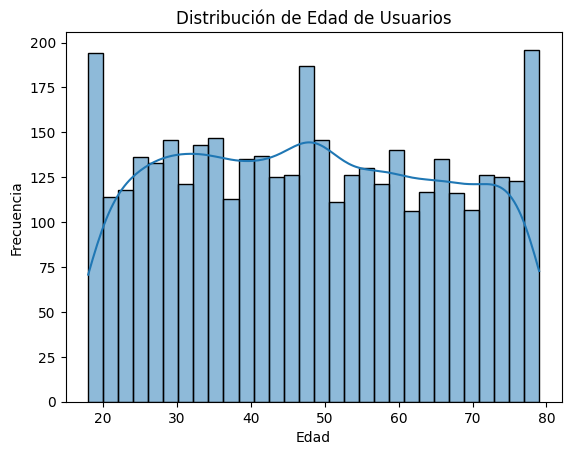

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=30, kde=True)
plt.title('Distribución de Edad de Usuarios')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución campana, podemos ver que no tenemos outliers o edades extremas, la mayoría de usuarios se concentra entre los 45 y 50 años aunque también hay bastante cantidad de usuarios jóvenes menores a 25 años y adultos mayores arriba de 75.

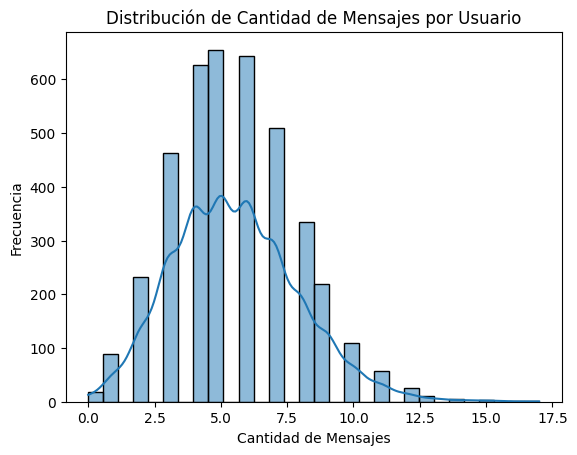

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=30, kde=True)
plt.title('Distribución de Cantidad de Mensajes por Usuario')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha, podemos ver que tenemos muchos usuarios con pocos mensajes y algunos pocos usuarios que envían muchos mensajes.

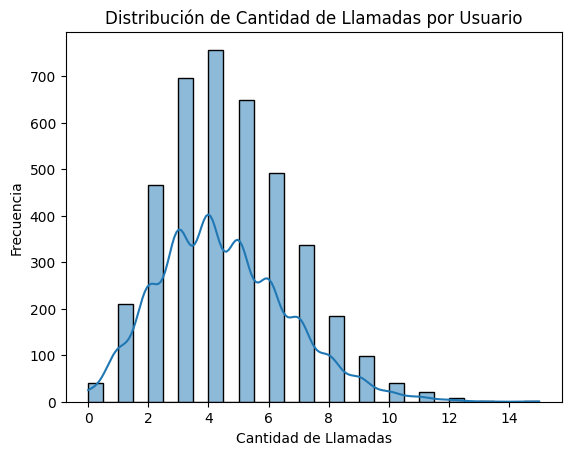

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=30, kde=True)
plt.title('Distribución de Cantidad de Llamadas por Usuario')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha de igual manera que en la cantidad de mensajes. Contamos con pocos usuarios que hacen muchas llamadas, y son muchos los usuarios que hacen pocas.

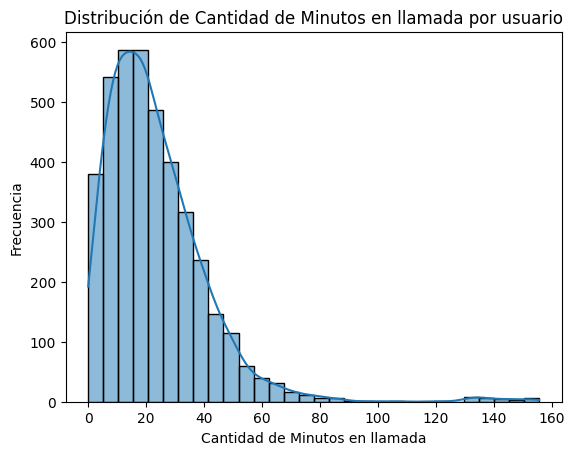

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=30, kde=True)
plt.title('Distribución de Cantidad de Minutos en llamada por usuario')
plt.xlabel('Cantidad de Minutos en llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Nuevamente nuestra distribución está sesgada a la derecha, aunque se logran ver a más usuarios que tienen más de dos horas por llamada. Sin embargo el punto más alto son aquellos usuarios que mantienen llamadas menores a 30 minutos

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

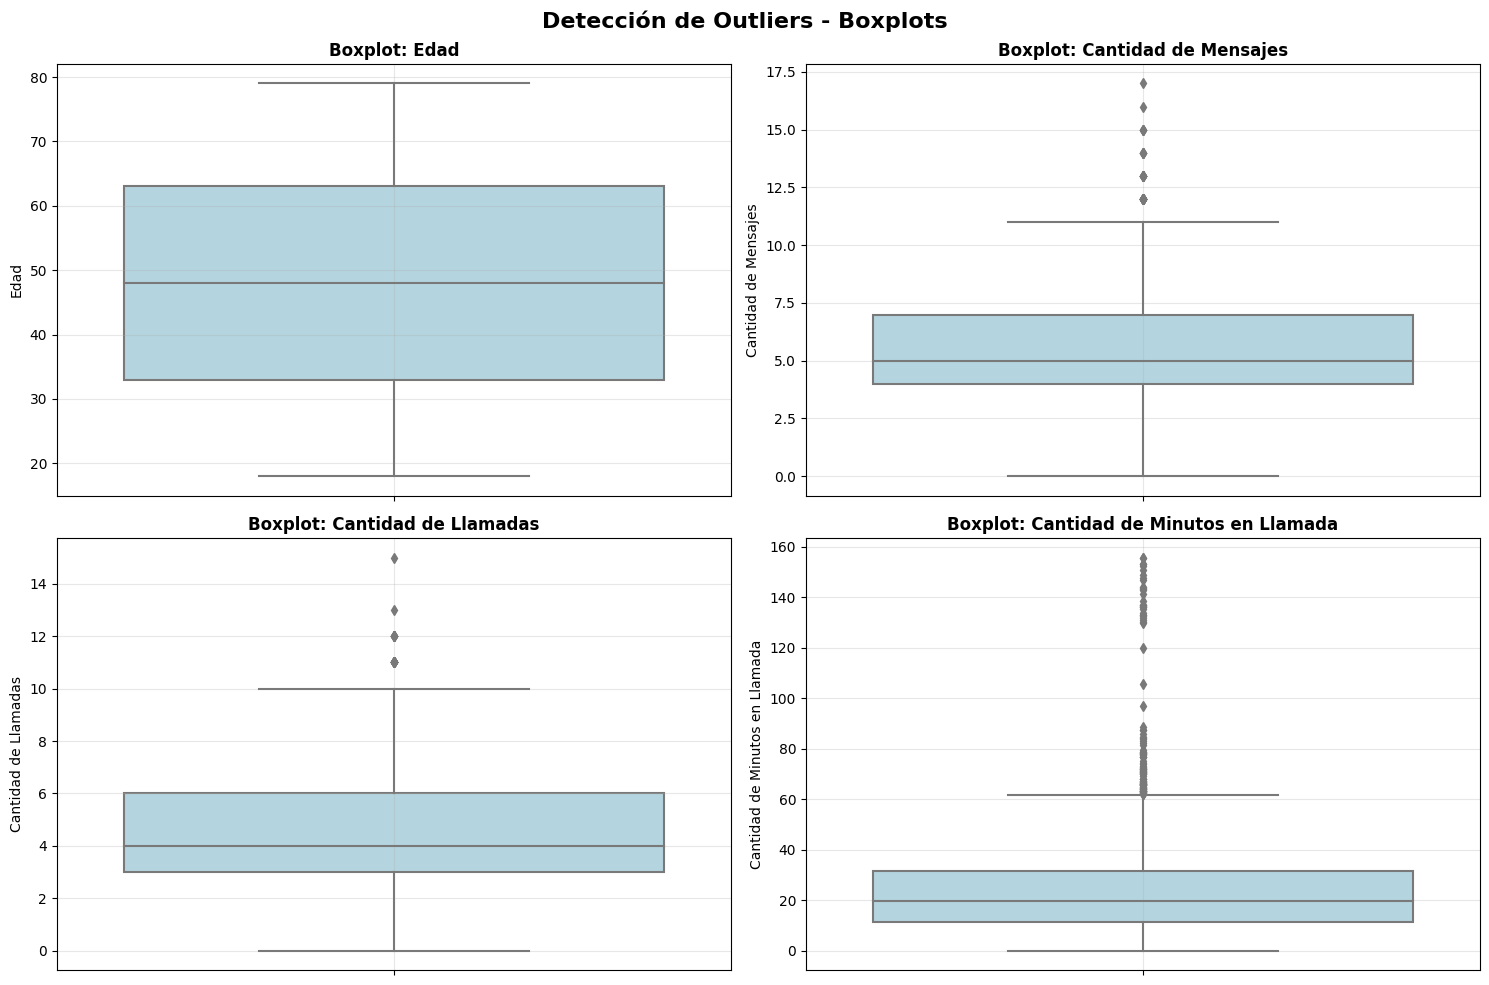

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
titulos = ['Edad', 'Cantidad de Mensajes', 'Cantidad de Llamadas', 'Cantidad de Minutos en Llamada']

# Crear subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Detección de Outliers - Boxplots', fontsize=16, fontweight='bold')

# Aplanar axes para facilitar iteración
axes = axes.flatten()

# Bucle para crear boxplots
for i, (col, titulo) in enumerate(zip(columnas_numericas, titulos)):
    sns.boxplot(data=user_profile, y=col, ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot: {titulo}', fontweight='bold')
    axes[i].set_ylabel(titulo)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

💡Insights: 
- Age: No presenta Outliers
- cant_mensajes: Cuenta con 6 usuarios Outliers los cuales son mayores a 10 mensajes
- cant_llamadas: Se tienen 4 usuarios Outliers mayores a 10 llamadas
- cant_minutos_llamada: Aquí contamos con más de 15 Outliers, mayores a 1 Hr de tiempo en llamada. los cuales se acumulan entre los 60 minutos y 1 hr y media de llamada, o bien de 2 horas hasta 2 hrs y media.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for columna in columnas_limites:
    Q1 = user_profile[columna].quantile(0.25)
    Q3 = user_profile[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Contar outliers
    outliers_inf = user_profile[user_profile[columna] < limite_inferior]
    outliers_sup = user_profile[user_profile[columna] > limite_superior]
    
    print(f"=== {columna.upper()} ===")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Outliers inferiores: {len(outliers_inf)}")
    print(f"Outliers superiores: {len(outliers_sup)}")
    print(f"Total outliers: {len(outliers_inf) + len(outliers_sup)}")
    print("-" * 30)


=== AGE ===
Límite inferior: -12.00
Límite superior: 108.00
Outliers inferiores: 0
Outliers superiores: 0
Total outliers: 0
------------------------------
=== CANT_MENSAJES ===
Límite inferior: -0.50
Límite superior: 11.50
Outliers inferiores: 0
Outliers superiores: 46
Total outliers: 46
------------------------------
=== CANT_LLAMADAS ===
Límite inferior: -1.50
Límite superior: 10.50
Outliers inferiores: 0
Outliers superiores: 30
Total outliers: 30
------------------------------
=== CANT_MINUTOS_LLAMADA ===
Límite inferior: -19.32
Límite superior: 61.86
Outliers inferiores: 0
Outliers superiores: 109
Total outliers: 109
------------------------------


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
  podemos mantenerlos, es realista el resultado, los que envían más de 10 mensajes, son usuarios valiosos, no errores de datos.
- cant_llamadas: mantener o no outliers, porqué?
  al igual que en mensajes, el resultado es perfectamente normal para usuarios activos, los que hacen de 10 a 15 llamadas representan heavy users, no anomalías.
- cant_minutos_llamada: mantener o no outliers, porqué?
  hay que revisar los outliers, porque del Q1 al máximo, es un salto de tiempo demaciado alto, las llamadas mayores a 100 minutos podrían ser errores de sistema.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 
        'Uso medio',
        'Alto uso'
    )
)

In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    (user_profile['age'] < 30), 
    'Joven',
    np.where(
        (user_profile['age'] < 60), 
        'Adulto',
        'Adulto Mayor'
    )
)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

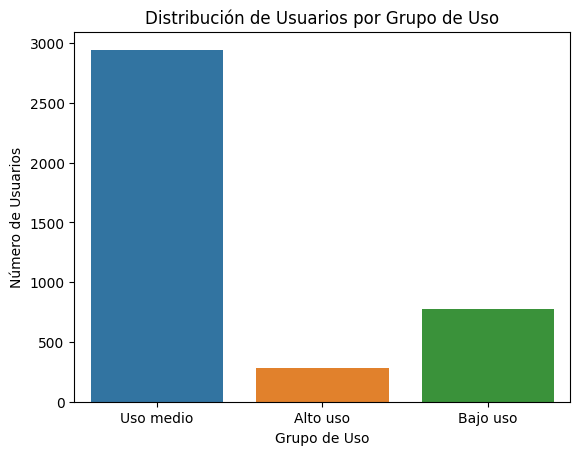

In [42]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Número de Usuarios')
plt.show()

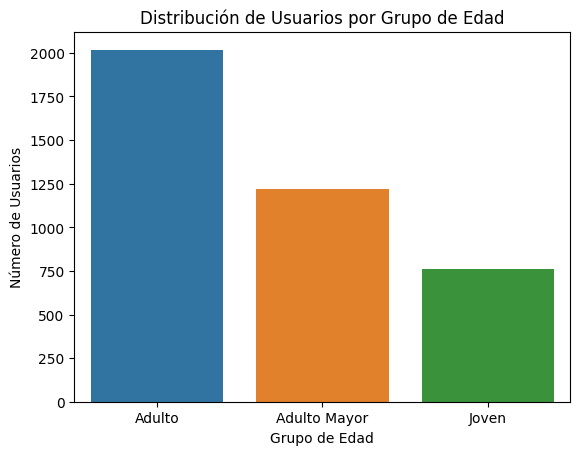

In [43]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Número de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
    El problema original eran los datos inválidos o nulos que existían, se contaba en algunas columnas con aproximadamente el 50% de nulos, los cuales tuvimos que verificar y reacomodar.
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
    Lo que podemos ver es que los usuarios jovenes no usan tanto el servicio como los usuarios adultos.
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
    Los usuarios adultos son quienes más impacto tienen en la empresa, porque son los que mayor utilización manejan
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
    Se encontraron outliers en mensajes y en tiempo de llamadas, sin embargo el único que se tiene que revisar para confirmar que sean o no error son las llamadas mayores a 100 minutos. 
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
    Recomendaría enfocar los planes a mejorar los mensajes ya que es el servicio más usados donde hay outliers validos. Se puede mejorar ese servicio, y también encontrar la forma de seguir atrayendo público adulto ya que es el que más provecho saca del servicio.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Outliers en tiempo de llamada, valores demasiado altos y un salto del Q3 al valor max.
- Datos nulos en ciudad, se tuvieron que sustituir datos.
- La columna de churn_date no tiene datos útiles por lo que la eliminamos.


🔍 **Segmentos por Edad**
- Se cuenta con una población mayor de Adultos
- Los usuarios que menos utilizan el servicio son Jóvenes 


📊 **Segmentos por Nivel de Uso**
- En su mayoría, los usuarios tienen un uso regular del servicio
- Solo pocos usuarios tienen un uso mayor a los demás


➡️ Esto sugiere que se debería de enfocar el servicio en mantener a nuestros clientes adultos quienes son los que más uso tienen y dar mejores planes a los usuarios premium que tienen uso alto.


💡 **Recomendaciones**
- Agregar planes para clientes premium.
- Mejorar planes para clientes regulares.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`